In [1]:
!pip install geopy folium

In [2]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import folium
import matplotlib.pyplot as plt
from google.colab import files


In [3]:
uploaded = files.upload()

Saving sensor_data_export_20250606_154020.csv to sensor_data_export_20250606_154020.csv


In [4]:
df = pd.read_csv('sensor_data_export_20250606_154020.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [5]:
gps_data = df[['timestamp', 'latitude', 'longitude', 'speed']].copy()

In [6]:
distances = [0.0]
for i in range(1, len(gps_data)):
    prev = (gps_data.loc[i-1, 'latitude'], gps_data.loc[i-1, 'longitude'])
    curr = (gps_data.loc[i, 'latitude'], gps_data.loc[i, 'longitude'])
    distance = geodesic(prev, curr).meters
    distances.append(distance)

gps_data['distance_m'] = distances
gps_data['cumulative_distance_m'] = np.cumsum(distances)
gps_data['time_diff_s'] = gps_data['timestamp'].diff().dt.total_seconds().fillna(0)
gps_data['estimated_speed_mps'] = gps_data['distance_m'] / gps_data['time_diff_s'].replace(0, np.nan)
gps_data['final_speed_mps'] = gps_data['speed'].fillna(gps_data['estimated_speed_mps'])


In [7]:
total_distance = gps_data['cumulative_distance_m'].iloc[-1]
average_speed = gps_data['final_speed_mps'].mean()
moving_duration = gps_data[gps_data['final_speed_mps'] > 0.5]['time_diff_s'].sum()

In [8]:
print(f"Total Distance Traveled: {total_distance:.2f} meters")
print(f"Average Speed: {average_speed:.2f} m/s")
print(f"Total Time Moving: {moving_duration:.2f} seconds")

Total Distance Traveled: 1075.87 meters
Average Speed: 0.29 m/s
Total Time Moving: 428.32 seconds


In [9]:
route_points = gps_data[['latitude', 'longitude']].dropna().values.tolist()
route_map = folium.Map(location=route_points[0], zoom_start=16)

folium.PolyLine(route_points, color='blue', weight=4.5, opacity=0.7).add_to(route_map)
folium.Marker(route_points[0], tooltip="Start", icon=folium.Icon(color='green')).add_to(route_map)
folium.Marker(route_points[-1], tooltip="End", icon=folium.Icon(color='red')).add_to(route_map)


In [10]:
route_map.save("gps_route_map.html")
files.download("gps_route_map.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

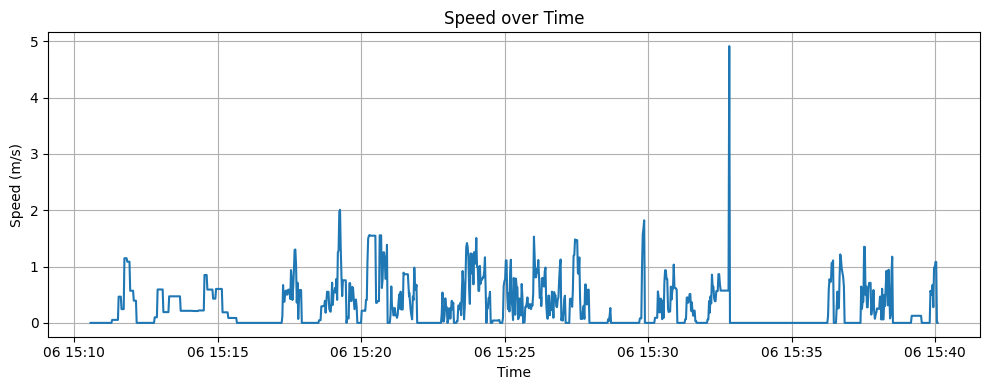

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(gps_data['timestamp'], gps_data['final_speed_mps'], label="Speed (m/s)")
plt.xlabel("Time")
plt.ylabel("Speed (m/s)")
plt.title("Speed over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("speed_over_time_plot.png")
plt.show()
files.download("speed_over_time_plot.png")
